<a href="https://colab.research.google.com/github/diazveraserrano-boop/-Deep-Learning-Based-Automated-Cell-Viability-Analysis-/blob/main/DL_Based_Cell_Viability_Assay.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning-Based Cell Viability Assay

**Automated live/dead cell counting via semantic segmentation (UNet + ResNet50)**

---

## Overview

This notebook implements a deep learning pipeline for automated cell viability assessment from fluorescence microscopy images. The model performs **semantic segmentation** to classify each pixel as one of three classes:

| Class | Label | Colour in mask |
|-------|-------|----------------|
| 0 | Background | Black `(0, 0, 0)` |
| 1 | Live cell | Green `(0, 180, 60)` |
| 2 | Dead cell | Red `(220, 50, 50)` |

Cell counts are then derived from the segmentation maps using a **gradient-guided watershed** algorithm, and viability is reported as:

$$\text{Viability (%)} = \frac{N_{\text{live}}}{N_{\text{live}} + N_{\text{dead}}} \times 100$$

### Architecture
- **Backbone:** ResNet-50 (ImageNet pre-trained, fine-tuned end-to-end)  
- **Head:** UNet decoder with skip connections  
- **Loss:** 50 % Categorical Focal Loss + 50 % Dice Loss  
- **Training strategy:** Priority patch sampling

### Notebook structure
1. Environment setup & data loading  
2. Dataset pipeline (patch extraction with class-balanced sampling)  
3. Model definition, compilation, and training  
4. Model loading & inference functions  
5. Quantitative evaluation (segmentation + counting metrics)  
6. Visualisation and figure export

---
> **Requirements:** Google Colab (GPU recommended), Google Drive with dataset mounted at the paths defined in Cell 1.  
> **Citation:** If you use this code, please cite the associated publication.


## 1 · Environment Setup and Data Loading

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 · Mount Google Drive and import libraries
# ─────────────────────────────────────────────────────────────────────────────
# Google Drive is required to access the dataset and saved model weights.
# All dataset images and segmentation masks must be stored there before running.

from google.colab import drive
drive.mount('/content/drive')

# ── Standard library ─────────────────────────────────────────────────────────
import os
import json
import random
import pickle

# ── Numerical & image processing ─────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import cv2                                       # OpenCV: image I/O, contours

# ── Deep learning (TensorFlow / Keras) ───────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import load_model

# ── Scientific image analysis (scikit-image / scipy) ─────────────────────────
from scipy import ndimage as ndi                 # Distance transform, Gaussian
from skimage.segmentation import watershed       # Instance separation
from skimage.feature import peak_local_max       # Local maxima (seed detection)
from skimage.morphology import remove_small_objects  # Remove noise artefacts
from skimage.filters import sobel                # Edge gradient for watershed

# ── Evaluation ───────────────────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure segmentation_models uses tf.keras (not standalone Keras)
os.environ['SM_FRAMEWORK'] = 'tf.keras'

# ── Dataset paths ─────────────────────────────────────────────────────────────
# Adjust these paths to match your Google Drive folder structure.
images_dir = "/content/drive/MyDrive/FINAL_IMAGES(sin_augmentation)"
masks_dir  = "/content/drive/MyDrive/FINAL_MASKS(sin_augmentation)"

# Collect and sort filenames to guarantee paired image–mask alignment
images = sorted([f for f in os.listdir(images_dir)
                 if f.endswith(('.png', '.jpg', '.tiff'))])
masks  = sorted([f for f in os.listdir(masks_dir)
                 if f.endswith(('.png', '.jpg', '.tiff'))])

print(f"Images: {len(images)}")
print(f"Masks:  {len(masks)}")
print("First 5 images:", images[:5])
print("First 5 masks:",  masks[:5])

# Safety check: every image must have a corresponding mask
assert len(images) == len(masks), "Number of images ≠ masks"
print("Directories verified — dataset is complete")

Mounted at /content/drive
Images: 96
Masks:  96
First 5 images: ['Image0001.jpg', 'Image0002.jpg', 'Image0003.jpg', 'Image0004.jpg', 'Image0005.jpg']
First 5 masks: ['Image0001mask.png', 'Image0002mask.png', 'Image0003mask.png', 'Image0004mask.png', 'Image0005mask.png']
Directories verified


## 2 · Dataset Pipeline

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 · Install segmentation-models and verify GPU availability
# ─────────────────────────────────────────────────────────────────────────────
# segmentation-models provides the UNet architecture with pre-built backbones.
# Installation is done here so the notebook is self-contained on a fresh Colab.

!pip install -q segmentation-models

import segmentation_models as sm

print("Libraries installed successfully")
print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 5.0 MB/s eta 0:00:00
Segmentation Models: using `tf.keras` framework.
Libraries installed successfully
TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 · Training pipeline configuration and dataset functions
# ─────────────────────────────────────────────────────────────────────────────

# ── Hyperparameters ───────────────────────────────────────────────────────────
IMG_SIZE   = 256   # Spatial size of each square patch fed to the model (px)
BATCH_SIZE = 8     # Number of patches per gradient-update step

# ── Patch sampling strategy ───────────────────────────────────────────────────
# To counteract class imbalance (dead cells are sparse) and that in green cells is difficult to determine the borders, each full image
# yields PATCHES_PER_IMAGE crops with the following breakdown:
#   • RED_PATCHES_PER_IMAGE   – crops that must contain ≥ MIN_RED_PIXELS dead cells
#   • GREEN_PATCHES_PER_IMAGE – crops that must contain ≥ MIN_GREEN_PIXELS live cells
#   • GENERAL_PATCHES_PER_IMAGE – unrestricted crops (background + mixed)
PATCHES_PER_IMAGE         = 7
RED_PATCHES_PER_IMAGE     = 1
GREEN_PATCHES_PER_IMAGE   = 4
GENERAL_PATCHES_PER_IMAGE = 2

MIN_CELL_FRACTION   = 0.01   # Minimum fraction of cell pixels in a general patch
MIN_RED_PIXELS      = 20     # Minimum dead-cell pixels required in a red patch
MIN_GREEN_PIXELS    = 50     # Minimum live-cell pixels required in a green patch
MAX_TRIES_PER_PATCH = 20     # Candidate patches evaluated before accepting the best

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Train / validation split (80 / 20, stratified by shuffle seed) ────────────
images_shuffled = images.copy()
random.shuffle(images_shuffled)

split       = int(0.8 * len(images_shuffled))
train_files = images_shuffled[:split]
val_files   = images_shuffled[split:]

# ─────────────────────────────────────────────────────────────────────────────
# Dataset pipeline helper functions
# ─────────────────────────────────────────────────────────────────────────────

def build_mask_path(img_file):
    """Construct the corresponding mask path for a given image filename.

    Images are named 'ImageNNNN.ext'; masks are named 'ImageNNNNmask.png'.
    This function zero-pads the numeric index to 4 digits inside a TF graph,
    using tf.cond chains (compatible with tf.data.Dataset.map).

    Args:
        img_file: Scalar string tensor — e.g. 'Image0011.jpg'.

    Returns:
        Scalar string tensor with the absolute mask path.
    """
    num_str = tf.strings.regex_replace(img_file, r'Image(\d+).*', r'\1')
    num_int = tf.strings.to_number(num_str, out_type=tf.int32)
    num_str = tf.strings.as_string(num_int)
    length  = tf.strings.length(num_str)

    zeros = tf.cond(
        length < 1, lambda: "0000",
        lambda: tf.cond(
            length < 2, lambda: tf.strings.join(["000", num_str]),
            lambda: tf.cond(
                length < 3, lambda: tf.strings.join(["00", num_str]),
                lambda: tf.cond(
                    length < 4, lambda: tf.strings.join(["0", num_str]),
                    lambda: num_str
                )
            )
        )
    )

    mask_file = tf.strings.join(["Image", zeros, "mask.png"])
    return tf.strings.join([masks_dir, "/", mask_file])


def load_full_sample(img_file):
    """Load a full-resolution image and its corresponding class mask.

    The RGB segmentation mask encodes classes by colour proximity:
        • Black  (0,   0,   0)   → background (class 0)
        • Green  (0,   180, 60)  → live cell  (class 1)
        • Red    (220, 50,  50)  → dead cell  (class 2)

    Colour distances are computed in L2 (Euclidean) space with a threshold
    of 60 intensity units to accommodate slight JPEG compression artefacts.

    Args:
        img_file: Filename string tensor (e.g. 'Image0011.jpg').

    Returns:
        img        : Float32 tensor [H, W, 3] — raw pixel values.
        mask_class : Int32  tensor [H, W]     — per-pixel class index (0/1/2).
    """
    img_path  = tf.strings.join([images_dir, "/", img_file])
    mask_path = build_mask_path(img_file)

    img  = tf.io.read_file(img_path)
    img  = tf.io.decode_image(img, channels=3, expand_animations=False)
    img  = tf.cast(img, tf.float32)

    mask = tf.io.read_file(mask_path)
    mask = tf.io.decode_image(mask, channels=3, expand_animations=False)
    mask = tf.cast(mask, tf.float32)

    # Assign each pixel to the nearest class centroid in RGB space
    dist_background = tf.norm(mask - [0,   0,   0 ], axis=-1)
    dist_green      = tf.norm(mask - [0,   180, 60], axis=-1)
    dist_red        = tf.norm(mask - [220, 50,  50], axis=-1)

    threshold  = 60.0
    mask_class = tf.where(dist_background < threshold, 0,
                          tf.zeros_like(dist_background, dtype=tf.int32))
    mask_class = tf.where(dist_green < threshold, 1, mask_class)
    mask_class = tf.where(dist_red   < threshold, 2, mask_class)

    return img, mask_class


def sample_random_patch(img, mask_class, patch_size=256):
    """Sample a random square crop from a full-resolution image.

    Args:
        img        : Float32 tensor [H, W, 3].
        mask_class : Int32  tensor [H, W].
        patch_size : Side length of the square crop (pixels).

    Returns:
        img_patch  : Float32 tensor [patch_size, patch_size, 3].
        mask_patch : Int32  tensor [patch_size, patch_size].
    """
    h = tf.shape(img)[0]
    w = tf.shape(img)[1]

    y = tf.random.uniform([], 0, h - patch_size + 1, dtype=tf.int32)
    x = tf.random.uniform([], 0, w - patch_size + 1, dtype=tf.int32)

    img_patch  = img[y:y+patch_size, x:x+patch_size, :]
    mask_patch = mask_class[y:y+patch_size, x:x+patch_size]

    return img_patch, mask_patch


def patch_stats(mask_patch):
    """Compute per-patch statistics used for priority-based sampling.

    Args:
        mask_patch: Int32 tensor [patch_size, patch_size].

    Returns:
        red_pixels    : Number of dead-cell pixels (class 2).
        green_pixels  : Number of live-cell pixels (class 1).
        cell_fraction : Fraction of pixels belonging to any cell (class > 0).
    """
    red_pixels    = tf.reduce_sum(tf.cast(mask_patch == 2, tf.int32))
    green_pixels  = tf.reduce_sum(tf.cast(mask_patch == 1, tf.int32))
    cell_fraction = tf.reduce_mean(tf.cast(mask_patch > 0, tf.float32))
    return red_pixels, green_pixels, cell_fraction


def sample_patch_by_priority(img, mask_class, priority="general",
                              patch_size=256, max_tries=20):
    """Sample the best patch from multiple candidates according to a priority.

    Generates `max_tries` random crops, scores each one by the given priority,
    and returns either a randomly chosen valid patch (if any exist) or the
    highest-scoring patch as a fallback.

    Priority modes:
        'red'     – maximise dead-cell pixel count  (≥ MIN_RED_PIXELS)
        'green'   – maximise live-cell pixel count  (≥ MIN_GREEN_PIXELS)
        'general' – maximise overall cell coverage  (≥ MIN_CELL_FRACTION)

    Args:
        img        : Float32 tensor [H, W, 3].
        mask_class : Int32  tensor [H, W].
        priority   : Sampling priority ('red' | 'green' | 'general').
        patch_size : Side length of the square crop (pixels).
        max_tries  : Number of candidate patches to evaluate.

    Returns:
        Best (img_patch, mask_patch) pair according to the priority criterion.
    """
    all_img_patches  = tf.TensorArray(tf.float32, size=max_tries)
    all_mask_patches = tf.TensorArray(tf.int32,   size=max_tries)
    all_scores       = tf.TensorArray(tf.float32, size=max_tries)
    all_valids       = tf.TensorArray(tf.bool,    size=max_tries)

    for i in tf.range(max_tries):
        img_patch, mask_patch = sample_random_patch(img, mask_class,
                                                    patch_size=patch_size)
        red_pixels, green_pixels, cell_fraction = patch_stats(mask_patch)

        if priority == "red":
            valid = red_pixels >= MIN_RED_PIXELS
            score = tf.cast(red_pixels, tf.float32)
        elif priority == "green":
            valid = green_pixels >= MIN_GREEN_PIXELS
            score = tf.cast(green_pixels, tf.float32)
        else:  # general
            valid = cell_fraction >= MIN_CELL_FRACTION
            score = cell_fraction

        all_img_patches  = all_img_patches.write(i,  img_patch)
        all_mask_patches = all_mask_patches.write(i, mask_patch)
        all_scores       = all_scores.write(i, score)
        all_valids       = all_valids.write(i, valid)

    all_img_patches  = all_img_patches.stack()
    all_mask_patches = all_mask_patches.stack()
    all_scores       = all_scores.stack()
    all_valids       = all_valids.stack()

    valid_indices = tf.where(all_valids)[:, 0]
    num_valid     = tf.shape(valid_indices)[0]

    def pick_valid_patch():
        # Randomly select among patches that satisfy the validity criterion
        random_idx = tf.random.uniform([], 0, num_valid, dtype=tf.int32)
        chosen_idx = valid_indices[random_idx]
        return all_img_patches[chosen_idx], all_mask_patches[chosen_idx]

    def pick_best_score_patch():
        # Fallback: return the highest-scoring patch even if below threshold
        best_score_idx = tf.argmax(all_scores)
        return all_img_patches[best_score_idx], all_mask_patches[best_score_idx]

    return tf.cond(num_valid > 0, pick_valid_patch, pick_best_score_patch)


def preprocess_patch(img_patch, mask_patch, preprocess_input, augment=False):
    """Apply backbone pre-processing and optional data augmentation to a patch.

    Pre-processing normalises pixel values to the statistics expected by the
    ImageNet-pretrained ResNet-50 backbone.

    Augmentation (training only) applies:
        • Horizontal flip  (p = 0.50)
        • Vertical   flip  (p = 0.30)
        • 90° rotation     (p = 0.30, k ∈ {0,1,2,3})
        • Brightness jitter (max_delta = 0.20)
        • Contrast   jitter (factor ∈ [0.80, 1.20])

    All spatial transforms are applied identically to the image and its mask
    to preserve pixel-level alignment.

    Args:
        img_patch        : Float32 tensor [H, W, 3] — raw pixel values.
        mask_patch       : Int32   tensor [H, W]    — class indices.
        preprocess_input : Backbone-specific normalisation function.
        augment          : Whether to apply stochastic augmentation.

    Returns:
        img_patch  : Normalised (and optionally augmented) image tensor.
        mask_onehot: Float32 one-hot mask tensor [H, W, 3].
    """
    img_patch   = preprocess_input(img_patch)
    mask_onehot = tf.one_hot(mask_patch, depth=3)
    mask_onehot = tf.cast(mask_onehot, tf.float32)

    if augment:
        if tf.random.uniform(()) > 0.5:
            img_patch   = tf.image.flip_left_right(img_patch)
            mask_onehot = tf.image.flip_left_right(mask_onehot)
        if tf.random.uniform(()) > 0.7:
            img_patch   = tf.image.flip_up_down(img_patch)
            mask_onehot = tf.image.flip_up_down(mask_onehot)
        if tf.random.uniform(()) > 0.7:
            k           = tf.random.uniform([], 0, 4, dtype=tf.int32)
            img_patch   = tf.image.rot90(img_patch,   k=k)
            mask_onehot = tf.image.rot90(mask_onehot, k=k)
        if tf.random.uniform(()) > 0.5:
            img_patch = tf.image.random_brightness(img_patch, max_delta=0.2)
        if tf.random.uniform(()) > 0.5:
            img_patch = tf.image.random_contrast(img_patch, lower=0.8, upper=1.2)

    return img_patch, mask_onehot


def extract_patches_from_image(img_file, preprocess_input, augment=False):
    """Extract all priority-sampled patches from a single full-resolution image.

    Combines red, green, and general patches according to the counts defined
    in the global configuration (PATCHES_PER_IMAGE and its breakdown).

    Args:
        img_file         : Image filename string (e.g. 'Image0011.jpg').
        preprocess_input : Backbone-specific normalisation function.
        augment          : Whether to apply stochastic augmentation.

    Returns:
        img_patches : Float32 tensor [PATCHES_PER_IMAGE, H, W, 3].
        mask_patches: Float32 tensor [PATCHES_PER_IMAGE, H, W, 3] — one-hot.
    """
    img, mask_class = load_full_sample(img_file)

    img_patches  = []
    mask_patches = []

    priorities = (
        ["red"]     * RED_PATCHES_PER_IMAGE   +
        ["green"]   * GREEN_PATCHES_PER_IMAGE +
        ["general"] * GENERAL_PATCHES_PER_IMAGE
    )

    for priority in priorities:
        img_patch, mask_patch = sample_patch_by_priority(
            img, mask_class,
            priority=priority,
            patch_size=IMG_SIZE,
            max_tries=MAX_TRIES_PER_PATCH
        )
        img_patch, mask_patch = preprocess_patch(
            img_patch, mask_patch,
            preprocess_input=preprocess_input,
            augment=augment
        )
        img_patches.append(img_patch)
        mask_patches.append(mask_patch)

    img_patches  = tf.stack(img_patches,  axis=0)
    mask_patches = tf.stack(mask_patches, axis=0)

    return img_patches, mask_patches


def create_patch_dataset(image_files, preprocess_input,
                         batch_size=8, shuffle=True, augment=False):
    """Build a tf.data.Dataset of (image_patch, mask_patch) batches.

    The pipeline:
        1. Creates a dataset of filenames.
        2. (Optionally) shuffles filenames.
        3. Maps each filename to PATCHES_PER_IMAGE patch pairs in parallel.
        4. Unbatches so each patch is a standalone example.
        5. (Optionally) shuffles the patch-level buffer for better mixing.
        6. Batches to BATCH_SIZE and pre-fetches for throughput.

    Args:
        image_files      : List of image filenames to include.
        preprocess_input : Backbone-specific normalisation function.
        batch_size       : Patches per mini-batch.
        shuffle          : Whether to shuffle filenames and patches.
        augment          : Whether to apply stochastic augmentation.

    Returns:
        A tf.data.Dataset yielding (img_batch, mask_batch) tuples.
    """
    dataset = tf.data.Dataset.from_tensor_slices(image_files)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(image_files),
                                  reshuffle_each_iteration=True)

    def map_fn(img_file):
        return extract_patches_from_image(
            img_file,
            preprocess_input=preprocess_input,
            augment=augment
        )

    dataset = dataset.map(map_fn, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch()

    if shuffle:
        dataset = dataset.shuffle(buffer_size=500, reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset

## 3 · Model Definition and Training

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 · Model definition — UNet with ResNet-50 backbone
# ─────────────────────────────────────────────────────────────────────────────
# Architecture: UNet encoder–decoder with a ResNet-50 encoder.
#
# The encoder is initialised with ImageNet weights and fine-tuned end-to-end
# (encoder_freeze=False). Skip connections from the encoder feed into the
# decoder at multiple resolutions, enabling precise localisation of small
# cell structures.
#
# Output layer: softmax over 3 classes (background / live / dead).

BACKBONE = 'resnet50'

# Retrieve the backbone-specific input normalisation function
preprocess_input = sm.get_preprocessing(BACKBONE)

model = sm.Unet(
    BACKBONE,
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    classes=3,                       # background, live cell, dead cell
    activation='softmax',
    encoder_weights='imagenet',      # Transfer learning from ImageNet
    encoder_freeze=False             # Fine-tune all encoder layers
)

print("UNet ResNet50 model created")


94592056/94592056 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
UNet ResNet50 model created


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 · Build training and validation tf.data pipelines
# ─────────────────────────────────────────────────────────────────────────────
# Training pipeline: shuffle + priority patch sampling + augmentation.
# Validation pipeline: fixed patches, no shuffle, no augmentation.

train_gen = create_patch_dataset(
    train_files,
    preprocess_input,
    batch_size=BATCH_SIZE,
    shuffle=True,
    augment=True       # Data augmentation enabled for training only
)

val_gen = create_patch_dataset(
    val_files,
    preprocess_input,
    batch_size=BATCH_SIZE,
    shuffle=False,
    augment=False      # Deterministic evaluation
)

print(f"Train:                {len(train_files)} images")
print(f"Val:                  {len(val_files)} images")
print(f"Patch size:           {IMG_SIZE}")
print(f"Patches per image:    {PATCHES_PER_IMAGE}")
print(f"  Red patches:        {RED_PATCHES_PER_IMAGE}")
print(f"  Green patches:      {GREEN_PATCHES_PER_IMAGE}")
print(f"  General patches:    {GENERAL_PATCHES_PER_IMAGE}")


Train:                76 images
Val:                  20 images
Patch size:           256
Patches per image:    7
Red patches:          1
Green patches:        4
General patches:      2


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 · Loss function, metrics, and model compilation
# ─────────────────────────────────────────────────────────────────────────────
# Loss = 0.5 × Focal Loss + 0.5 × Dice Loss
#
# Categorical Focal Loss addresses class imbalance by down-weighting easy
# background pixels (α_background = 0.2) and up-weighting rare cell classes
# (α_live = α_dead = 4.0). The focusing parameter γ = 2.0 further reduces the
# contribution of confidently classified pixels.
#
# Dice Loss optimises the overlap coefficient directly, which is more robust
# to imbalance than cross-entropy for segmentation tasks. Class weights
# [0, 1, 1] exclude the background from the Dice computation.
#
# Metrics: Intersection-over-Union (IoU) computed independently for live
# (green, class 1) and dead (red, class 2) cells at a 0.5 probability threshold.

focal_loss = sm.losses.CategoricalFocalLoss(
    alpha=[0.2, 4.0, 4.0],   # Per-class loss weights: [background, live, dead]
    gamma=2.0                 # Focusing parameter
)

dice_loss = sm.losses.DiceLoss(
    class_weights=[0.0, 1.0, 1.0]   # Ignore background in Dice computation
)

loss = 0.5 * focal_loss + 0.5 * dice_loss   # Combined loss

metrics = [
    sm.metrics.IOUScore(threshold=0.5, class_indexes=[1], name='iou_green'),
    sm.metrics.IOUScore(threshold=0.5, class_indexes=[2], name='iou_red')
]

optimizer = keras.optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=metrics
)

print("Model compiled with Focal + Dice loss")


Model compiled with Focal + Dice loss


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 · Training callbacks
# ─────────────────────────────────────────────────────────────────────────────
# Three callbacks control the training loop:
#
#   ModelCheckpoint  — saves the weights that achieve the highest validation
#                      IoU on live cells (val_iou_verde).
#   ReduceLROnPlateau — halves the learning rate after 4 epochs without
#                       improvement (minimum LR = 1 × 10⁻⁶).
#   EarlyStopping    — terminates training after 6 epochs without improvement
#                      and restores the best weights automatically.
#
# Note: the monitored metric name 'val_iou_verde' reflects the original
# Spanish naming convention used during development.

callbacks = [
    keras.callbacks.ModelCheckpoint(
        "/content/best_unet_focal_dice.keras",
        monitor='val_iou_verde',    # Monitor live-cell IoU on validation set
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_iou_verde',
        mode='max',
        patience=4,                 # Epochs to wait before reducing LR
        factor=0.5,                 # LR multiplier on plateau
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.EarlyStopping(
        monitor='val_iou_verde',
        mode='max',
        patience=6,                 # Epochs to wait before stopping
        restore_best_weights=True,  # Revert to best checkpoint on stop
        verbose=1
    )
]


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 · Model training
# ─────────────────────────────────────────────────────────────────────────────
# Trains for up to 20 epochs; EarlyStopping typically halts training earlier.
# The best checkpoint (highest val_iou_verde) is preserved by ModelCheckpoint
# and restored automatically by EarlyStopping at the end of training.
#
# Estimated training time: ~3–5 min/epoch on a Colab T4 GPU.

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=callbacks,
    verbose=2
)


Epoch 1/20

Epoch 1: val_iou_verde improved from None to 0.38432, saving model to /content/best_unet_focal_dice.keras

Epoch 1: finished saving model to /content/best_unet_focal_dice.keras
67/67 - 136s - 2s/step - iou_rojo: 0.0786 - iou_verde: 0.3912 - loss: 0.4682 - val_iou_rojo: 0.2556 - val_iou_verde: 0.3843 - val_loss: 0.4812 - learning_rate: 1.0000e-04
Epoch 2/20

Epoch 2: val_iou_verde improved from 0.38432 to 0.47821, saving model to /content/best_unet_focal_dice.keras

Epoch 2: finished saving model to /content/best_unet_focal_dice.keras
67/67 - 33s - 493ms/step - iou_rojo: 0.1027 - iou_verde: 0.5726 - loss: 0.4285 - val_iou_rojo: 0.1694 - val_iou_verde: 0.4782 - val_loss: 0.4559 - learning_rate: 1.0000e-04
Epoch 3/20

Epoch 3: val_iou_verde improved from 0.47821 to 0.55560, saving model to /content/best_unet_focal_dice.keras

Epoch 3: finished saving model to /content/best_unet_focal_dice.keras
67/67 - 33s - 494ms/step - iou_rojo: 0.1296 - iou_verde: 0.6118 - loss: 0.4136 - va

## 4 · Model Loading and Inference Functions

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 · Load a pre-trained model from Google Drive
# ─────────────────────────────────────────────────────────────────────────────
# Run this cell (instead of Cells 4–8) to skip training and load an already
# trained model directly. The model is loaded without re-compiling the loss so
# that it can be used with any custom inference routine.

model = load_model(
    "/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256/model.keras",
    compile=False   # Skip loss/metric compilation — inference only
)

preprocess_input = sm.get_preprocessing('resnet50')

print("Model loaded successfully")


Model loaded successfully


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 · Inference and post-processing functions
# ─────────────────────────────────────────────────────────────────────────────

# ── Post-processing hyperparameters ──────────────────────────────────────────
# CLASS_CONFIG controls the predicted segmentation post-processing.
# GT_CONFIG controls the ground-truth mask post-processing (used for counting).
#
# Key parameters:
#   min_prob       – probability threshold to binarise the softmax output
#   min_area_px    – minimum connected-component area to discard noise
#   min_distance   – minimum peak separation in the distance transform (px)
#   sigma          – Gaussian smoothing radius for the distance map
#   alpha          – blend factor between distance map and gradient terrain
#                    (higher α → distance-driven; lower α → edge-driven)

CLASS_CONFIG = {
    'green': {                 # Live cell (class 1) post-processing
        'idx':          1,
        'min_prob':     0.52,
        'min_area_px':  350,
        'min_distance': 35,
        'sigma':        4.5,
        'alpha':        0.6,
    },
    'red': {                   # Dead cell (class 2) post-processing
        'idx':          2,
        'min_prob':     0.45,
        'min_area_px':  40,
        'min_distance': 7,
        'sigma':        1.2,
        'alpha':        0.8,
    }
}

GT_CONFIG = {
    'green': {                 # Live cell counting from GT mask
        'min_area_px':  200,
        'min_distance': 20,
        'sigma':        3.0,
    },
    'red': {                   # Dead cell counting from GT mask
        'min_area_px':  30,
        'min_distance': 6,
        'sigma':        1.0,
    }
}


def predict_full_image(model, image, preprocess_input, patch_size=256, stride=128):
    """Run full-image inference using overlapping patches and test-time augmentation (TTA).

    Strategy:
        1. Slide a (patch_size × patch_size) window over the image with the
           given stride (50 % overlap by default).
        2. For each window position, apply 4 TTA variants (identity, horizontal
           flip, vertical flip, both flips) and average the softmax outputs
           after reversing each augmentation.
        3. Accumulate weighted probability sums and a coverage count map.
        4. Divide by the count map to obtain the averaged probability per pixel.

    Args:
        model            : Trained Keras model.
        image            : uint8 / float ndarray [H, W, 3] — RGB image.
        preprocess_input : Backbone-specific normalisation function.
        patch_size       : Side length of the sliding window (pixels).
        stride           : Step size of the sliding window (pixels).

    Returns:
        prob_map: Float32 ndarray [H, W, 3] — per-pixel class probabilities.
    """
    H, W = image.shape[:2]
    prob_sum  = np.zeros((H, W, 3), dtype=np.float32)
    count_map = np.zeros((H, W),    dtype=np.float32)

    # Define 4 TTA transforms and their corresponding inverse transforms
    ttas = [
        (lambda p: p,                lambda p: p),               # identity
        (lambda p: p[:, ::-1, :],    lambda p: p[:, ::-1, :]),   # h-flip
        (lambda p: p[::-1, :, :],    lambda p: p[::-1, :, :]),   # v-flip
        (lambda p: p[::-1, ::-1, :], lambda p: p[::-1, ::-1, :]),# both flips
    ]

    patches, positions, inv_fns = [], [], []
    for y in range(0, H - patch_size + 1, stride):
        for x in range(0, W - patch_size + 1, stride):
            patch = image[y:y+patch_size, x:x+patch_size].copy()
            for aug_fn, inv_fn in ttas:
                patches.append(preprocess_input(aug_fn(patch).astype(np.float32)))
                positions.append((y, x))
                inv_fns.append(inv_fn)

    # Batch model predictions (sub-batches of 16 to avoid OOM on large images)
    patches_arr = np.stack(patches)
    all_preds   = []
    for i in range(0, len(patches_arr), 16):
        all_preds.append(model.predict(patches_arr[i:i+16], verbose=0))
    all_preds = np.concatenate(all_preds, axis=0)

    # Accumulate de-augmented predictions into the full-image probability map
    for pred, (y, x), inv_fn in zip(all_preds, positions, inv_fns):
        prob_sum[y:y+patch_size, x:x+patch_size]  += inv_fn(pred)
        count_map[y:y+patch_size, x:x+patch_size] += 1

    return prob_sum / np.maximum(count_map[..., np.newaxis], 1)


def separate_instances(prob_map, image_gray, cfg):
    """Separate touching cells into individual instances via gradient-guided watershed.

    Pipeline:
        1. Threshold the softmax probability map to obtain a binary mask.
        2. Remove small connected components (noise artefacts).
        3. Compute the Euclidean distance transform of the binary mask.
        4. Detect local maxima in the smoothed distance map as cell-centre seeds.
        5. Build a composite terrain from the distance map and the Sobel edge
           gradient, weighted by `alpha`.
        6. Run marker-controlled watershed to delineate individual cells.

    Args:
        prob_map   : Float32 ndarray [H, W, 3] — softmax class probabilities.
        image_gray : uint8 ndarray [H, W]      — greyscale version of the input.
        cfg        : Configuration dict (one entry from CLASS_CONFIG).

    Returns:
        labels : Int32 ndarray [H, W] — instance label map (0 = background).
        n_cells: Integer count of detected cell instances.
    """
    prob   = prob_map[:, :, cfg['idx']]
    binary = prob > cfg['min_prob']
    binary = remove_small_objects(binary, min_size=cfg['min_area_px'])

    if not binary.any():
        return np.zeros_like(binary, dtype=np.int32), 0

    dist        = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=cfg['sigma'])
    coords      = peak_local_max(dist_smooth,
                                 min_distance=cfg['min_distance'],
                                 labels=binary)

    markers = np.zeros_like(binary, dtype=np.int32)
    for i, (r, c) in enumerate(coords):
        markers[r, c] = i + 1

    # Composite terrain: blend distance map (inverted) with Sobel edge gradient
    gradient = sobel(image_gray.astype(np.float32) / 255.0)
    terrain  = cfg['alpha'] * (1 - dist_smooth / (dist_smooth.max() + 1e-6)) + \
               (1 - cfg['alpha']) * gradient

    labels  = watershed(terrain, markers, mask=binary)
    n_cells = len(np.unique(labels)) - 1   # Subtract background label 0
    return labels, n_cells


def count_from_mask(binary_mask, cfg):
    """Count cells in a predicted binary mask using pure distance-transform watershed.

    Unlike `separate_instances`, this function uses only the distance transform
    (without the edge gradient) for counting, which is more robust when the
    greyscale image is not available.

    Args:
        binary_mask: Bool ndarray [H, W] — predicted binary segmentation.
        cfg        : Configuration dict (one entry from CLASS_CONFIG).

    Returns:
        Integer count of detected cells (≥ 0).
    """
    binary = remove_small_objects(binary_mask.astype(bool),
                                  min_size=cfg['min_area_px'])
    if not binary.any():
        return 0

    dist        = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=cfg['sigma'])
    coords      = peak_local_max(dist_smooth,
                                 min_distance=cfg['min_distance'],
                                 labels=binary)
    if len(coords) == 0:
        return 0

    markers = np.zeros_like(binary, dtype=np.int32)
    for i, (r, c) in enumerate(coords):
        markers[r, c] = i + 1

    labels  = watershed(-dist_smooth, markers, mask=binary)
    n_cells = len(np.unique(labels)) - 1
    return max(n_cells, 0)


def count_gt_from_mask(binary_mask, cfg):
    """Count cells in a ground-truth binary mask using fixed GT_CONFIG parameters.

    Identical algorithm to `count_from_mask` but uses GT_CONFIG thresholds,
    which are tuned to the ground-truth mask characteristics rather than the
    model output.

    Args:
        binary_mask: Bool ndarray [H, W] — GT binary segmentation.
        cfg        : Configuration dict (one entry from GT_CONFIG).

    Returns:
        Integer count of ground-truth cells (≥ 0).
    """
    binary = remove_small_objects(binary_mask.astype(bool),
                                  min_size=cfg['min_area_px'])
    if not binary.any():
        return 0

    dist        = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=cfg['sigma'])
    coords      = peak_local_max(dist_smooth,
                                 min_distance=cfg['min_distance'],
                                 labels=binary)
    if len(coords) == 0:
        return 0

    markers = np.zeros_like(binary, dtype=np.int32)
    for i, (r, c) in enumerate(coords):
        markers[r, c] = i + 1

    labels  = watershed(-dist_smooth, markers, mask=binary)
    n_cells = len(np.unique(labels)) - 1
    return max(n_cells, 0)


def parse_mask(mask_path):
    """Load and decode an RGB segmentation mask to a per-pixel class index map.

    Reads the PNG mask from disk, converts BGR→RGB, then assigns each pixel
    to the nearest class centroid using the same colour-distance logic as
    `load_full_sample` (but in NumPy rather than TensorFlow, for use outside
    the tf.data pipeline).

    Args:
        mask_path: Absolute path to the PNG mask file.

    Returns:
        mask_class: Int32 ndarray [H, W] — class indices (0=background,
                    1=live, 2=dead).
    """
    mask = cv2.imread(mask_path)
    mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB).astype(np.float32)

    dist_green = np.linalg.norm(mask - [0,   180, 60], axis=-1)
    dist_red   = np.linalg.norm(mask - [220, 50,  50], axis=-1)

    threshold  = 60.0
    mask_class = np.zeros(mask.shape[:2], dtype=np.int32)
    mask_class[dist_green < threshold] = 1
    mask_class[dist_red   < threshold] = 2

    return mask_class


def segmentation_metrics(gt_class, pred_class, n_classes=3):
    """Compute pixel-level segmentation metrics for each class.

    Calculates IoU, Dice coefficient, Precision, and Recall for each class
    by comparing predicted and ground-truth class maps pixel-by-pixel.
    A small epsilon (1e-8) is added to all denominators to avoid division by zero.

    Args:
        gt_class  : Int32 ndarray [H, W] — ground-truth class map.
        pred_class: Int32 ndarray [H, W] — predicted class map.
        n_classes : Number of classes (default: 3).

    Returns:
        Dictionary keyed by class name ('background', 'green', 'red'), each
        containing {'IoU', 'Dice', 'Precision', 'Recall'} as floats.
    """
    results = {}
    names   = ['background', 'green', 'red']

    for c in range(n_classes):
        gt_c   = (gt_class == c)
        pred_c = (pred_class == c)

        tp = np.logical_and(gt_c,  pred_c).sum()
        fp = np.logical_and(~gt_c, pred_c).sum()
        fn = np.logical_and(gt_c, ~pred_c).sum()

        iou       = tp / (tp + fp + fn + 1e-8)
        dice      = 2 * tp / (2 * tp + fp + fn + 1e-8)
        precision = tp / (tp + fp + 1e-8)
        recall    = tp / (tp + fn + 1e-8)

        results[names[c]] = {
            'IoU':       round(float(iou),       4),
            'Dice':      round(float(dice),      4),
            'Precision': round(float(precision), 4),
            'Recall':    round(float(recall),    4),
        }

    return results


def visualize_result(image, prob_map, labels_green, labels_red, n_green, n_red):
    """Display a 4-panel diagnostic figure for a single image prediction.

    Panels:
        1. Original fluorescence image.
        2. Semantic segmentation overlay (green / red masks blended with image).
        3. Instance segmentation with individual cell contours and counts.
        4. Smoothed distance map (hot colormap) — peaks correspond to cell centres.

    Args:
        image        : uint8 ndarray [H, W, 3] — original RGB image.
        prob_map     : Float32 ndarray [H, W, 3] — softmax probability map.
        labels_green : Int32 ndarray [H, W] — live-cell instance label map.
        labels_red   : Int32 ndarray [H, W] — dead-cell instance label map.
        n_green      : Detected live-cell count.
        n_red        : Detected dead-cell count.
    """
    fig, axes = plt.subplots(1, 4, figsize=(24, 6))

    total = n_green + n_red
    title = (f"Live cells: {n_green}  |  Dead cells: {n_red}  |  "
             f"Viability: {n_green/total*100:.1f}%") if total > 0 else "No cells detected"
    fig.suptitle(title, fontsize=14, fontweight='bold')

    # Panel 1 — original image
    axes[0].imshow(image)
    axes[0].set_title("Original image")
    axes[0].axis('off')

    # Panel 2 — semantic segmentation overlay
    overlay    = image.copy().astype(np.float32)
    green_mask = prob_map[:, :, 1] > CLASS_CONFIG['green']['min_prob']
    red_mask   = prob_map[:, :, 2] > CLASS_CONFIG['red']['min_prob']
    overlay[green_mask] = overlay[green_mask] * 0.4 + np.array([0, 200, 50])  * 0.6
    overlay[red_mask]   = overlay[red_mask]   * 0.4 + np.array([220, 30, 30]) * 0.6
    axes[1].imshow(overlay.clip(0, 255).astype(np.uint8))
    axes[1].set_title("Semantic segmentation")
    axes[1].axis('off')

    # Panel 3 — instance contours (green = live, red = dead)
    instance_vis = image.copy().astype(np.uint8)
    for lid in np.unique(labels_green):
        if lid == 0: continue
        mask = (labels_green == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (0, 255, 0), 2)
    for lid in np.unique(labels_red):
        if lid == 0: continue
        mask = (labels_red == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (255, 50, 50), 2)
    axes[2].imshow(instance_vis)
    axes[2].set_title(f"Separated instances (green={n_green}, red={n_red})")
    axes[2].axis('off')

    # Panel 4 — distance map (smoothed)
    dist_g = ndi.distance_transform_edt(
        prob_map[:, :, 1] > CLASS_CONFIG['green']['min_prob'])
    dist_r = ndi.distance_transform_edt(
        prob_map[:, :, 2] > CLASS_CONFIG['red']['min_prob'])
    diag   = np.maximum(
        ndi.gaussian_filter(dist_g, sigma=CLASS_CONFIG['green']['sigma']),
        ndi.gaussian_filter(dist_r, sigma=CLASS_CONFIG['red']['sigma'])
    )
    axes[3].imshow(diag, cmap='hot')
    axes[3].set_title("Distance map\n(peaks = cell centres)")
    axes[3].axis('off')

    plt.tight_layout()
    plt.show()

print("Functions ready")


Functions ready


## 5 · Quantitative Evaluation

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 11 · Compute and save fixed ground-truth (GT) cell counts
# ─────────────────────────────────────────────────────────────────────────────
# Ground-truth cell counts are derived from the annotated segmentation masks
# using the watershed algorithm with GT_CONFIG parameters (tuned separately
# from the prediction post-processing). Counts are computed once and saved to
# a JSON file so that the exact same GT reference is used across all evaluation
# runs — preventing variation caused by the stochastic components of watershed.
#
# Output file: gt_counts_fixed.json

save_dir = "/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256"
os.makedirs(save_dir, exist_ok=True)

SEED = 42
random.seed(SEED)
all_images = sorted([f for f in os.listdir(images_dir)
                     if f.endswith(('.png', '.jpg', '.tiff'))])
random.shuffle(all_images)
split          = int(0.8 * len(all_images))
val_files_full = all_images[split:]

print(f"Computing fixed GT for {len(val_files_full)} images...\n")
print(f"{'Image':<20} {'GT_green':>10} {'GT_red':>10}")
print("-" * 44)

GT_COUNTS = {}

for img_file in val_files_full:
    img_num   = ''.join(filter(str.isdigit, img_file.split('.')[0]))
    mask_file = f"Image{img_num.zfill(4)}mask.png"
    mask_path = os.path.join(masks_dir, mask_file)

    if not os.path.exists(mask_path):
        print(f"  {img_file}: mask not found, skipping...")
        continue

    gt_class = parse_mask(mask_path)
    n_green  = count_gt_from_mask(gt_class == 1, GT_CONFIG['green'])
    n_red    = count_gt_from_mask(gt_class == 2, GT_CONFIG['red'])

    GT_COUNTS[img_file] = {
        'green':     n_green,
        'red':       n_red,
        'total':     n_green + n_red,
        'viability': round(n_green / (n_green + n_red) * 100, 2)
                     if (n_green + n_red) > 0 else 0.0
    }

    print(f"{img_file:<20} {n_green:>10} {n_red:>10}")

# Save GT counts alongside their configuration for full reproducibility
gt_save = {
    'description': 'Fixed ground-truth cell counts via watershed on segmentation masks',
    'n_images':    len(GT_COUNTS),
    'GT_CONFIG':   GT_CONFIG,
    'counts':      GT_COUNTS
}

gt_path = os.path.join(save_dir, "gt_counts_fixed.json")
with open(gt_path, "w") as f:
    json.dump(gt_save, f, indent=2)

print(f"\nGT_COUNTS saved to: {gt_path}")


Computing fixed GT for 20 images...

Image                  GT_green     GT_red
--------------------------------------------
Image0096.jpg                45          1
Image0065.jpg                54          6
Image0030.jpg                44          9
Image0028.jpg                68         12
Image0086.jpg                60         20
Image0094.jpg                84          7
Image0005.jpg                44        154
Image0055.jpg                47          4
Image0076.jpg                26         14
Image0012.jpg               124          0
Image0070.jpg                24          2
Image0087.jpg               106         19
Image0014.jpg               139         33
Image0018.jpg                 0          2
Image0029.jpg                82         13
Image0032.jpg                86          5
Image0036.jpg                49         69
Image0004.jpg                50        171
Image0015.jpg                63          3
Image0082.jpg               192         11

GT_COUNTS save

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 12 · Full model evaluation on the validation set
# ─────────────────────────────────────────────────────────────────────────────
# For each validation image, this cell:
#   1. Loads the image and its ground-truth mask.
#   2. Runs full-image inference (overlapping patches + 4× TTA).
#   3. Computes pixel-level segmentation metrics (IoU, Dice, Precision, Recall).
#   4. Counts predicted cells via watershed and compares to fixed GT counts.
#
# Accumulated results are summarised at the end as mean ± std across all images.

with open("/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256/gt_counts_fixed.json") as f:
    gt_save   = json.load(f)
    GT_COUNTS = gt_save['counts']

print(f"GT loaded: {len(GT_COUNTS)} images")

SEED = 42
random.seed(SEED)
all_images = sorted([f for f in os.listdir(images_dir)
                     if f.endswith(('.png', '.jpg', '.tiff'))])
random.shuffle(all_images)
split     = int(0.8 * len(all_images))

val_files = [f for f in all_images[split:]]
print(f"Validation images: {len(val_files)}")

# Storage for per-image results (used later for visualisation)
prob_maps  = []
gt_classes = []
images_raw = []

# Flattened pixel samples for the confusion matrix (every 50th pixel to fit in RAM)
all_gt_flat, all_pred_flat = [], []

# Segmentation metric accumulators
seg_metrics_accum = {
    'background': {'IoU': [], 'Dice': [], 'Precision': [], 'Recall': []},
    'green':      {'IoU': [], 'Dice': [], 'Precision': [], 'Recall': []},
    'red':        {'IoU': [], 'Dice': [], 'Precision': [], 'Recall': []},
}

# Cell counting result lists
gt_counts_green, pred_counts_green = [], []
gt_counts_red,   pred_counts_red   = [], []

print("Evaluating...\n")

for img_file in val_files:
    img_num   = ''.join(filter(str.isdigit, img_file.split('.')[0]))
    mask_file = f"Image{img_num.zfill(4)}mask.png"
    img_path  = os.path.join(images_dir, img_file)
    mask_path = os.path.join(masks_dir,  mask_file)

    if not os.path.exists(mask_path) or img_file not in GT_COUNTS:
        print(f"  Skipping {img_file}...")
        continue

    image      = cv2.imread(img_path)
    image      = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gt_class   = parse_mask(mask_path)
    prob_map   = predict_full_image(model, image, preprocess_input)
    pred_class = np.argmax(prob_map, axis=-1).astype(np.int32)

    prob_maps.append(prob_map)
    gt_classes.append(gt_class)
    images_raw.append(image)

    metrics = segmentation_metrics(gt_class, pred_class)
    for cls in ['background', 'green', 'red']:
        for metric in ['IoU', 'Dice', 'Precision', 'Recall']:
            seg_metrics_accum[cls][metric].append(metrics[cls][metric])

    # Subsample pixels (stride=50) to keep confusion-matrix data manageable
    all_gt_flat.extend(gt_class.flatten()[::50].tolist())
    all_pred_flat.extend(pred_class.flatten()[::50].tolist())

    gt_green   = GT_COUNTS[img_file]['green']
    gt_red     = GT_COUNTS[img_file]['red']
    pred_green = count_from_mask(pred_class == 1, CLASS_CONFIG['green'])
    pred_red   = count_from_mask(pred_class == 2, CLASS_CONFIG['red'])

    gt_counts_green.append(gt_green)
    gt_counts_red.append(gt_red)
    pred_counts_green.append(pred_green)
    pred_counts_red.append(pred_red)

    print(f"  {img_file}: "
          f"GT=({gt_green} live, {gt_red} dead) | "
          f"Pred=({pred_green} live, {pred_red} dead) | "
          f"Diff=({pred_green-gt_green:+d} live, {pred_red-gt_red:+d} dead)")

print("\nEvaluation completed")

# ── Segmentation summary ──────────────────────────────────────────────────────
print("\n" + "="*66)
print("SEGMENTATION METRICS (mean ± std)")
print("="*66)
print(f"{'Class':<12} {'IoU':>10} {'Dice':>10} {'Precision':>12} {'Recall':>10}")
print("-"*66)

for cls, label in [('green', 'Live'), ('red', 'Dead'), ('background', 'Background')]:
    m = seg_metrics_accum[cls]
    print(f"{label:<12} "
          f"{np.mean(m['IoU']):.3f}±{np.std(m['IoU']):.3f}  "
          f"{np.mean(m['Dice']):.3f}±{np.std(m['Dice']):.3f}  "
          f"{np.mean(m['Precision']):.3f}±{np.std(m['Precision']):.3f}  "
          f"{np.mean(m['Recall']):.3f}±{np.std(m['Recall']):.3f}")

# ── Counting summary ──────────────────────────────────────────────────────────
gt_g   = np.array(gt_counts_green)
pred_g = np.array(pred_counts_green)
gt_r   = np.array(gt_counts_red)
pred_r = np.array(pred_counts_red)

def counting_metrics(gt, pred, name):
    """Print MAE, MAPE, R², and systematic bias for cell count predictions.

    Args:
        gt   : 1-D ndarray of ground-truth counts.
        pred : 1-D ndarray of predicted counts (same length as gt).
        name : Display name for the cell class.

    Returns:
        Tuple (MAE, MAPE, R², bias).
    """
    mae    = np.mean(np.abs(pred - gt))
    mask   = gt > 0
    mape   = np.mean(np.abs((pred[mask]-gt[mask])/gt[mask]))*100 if mask.any() else 0
    ss_res = np.sum((gt - pred)**2)
    ss_tot = np.sum((gt - np.mean(gt))**2)
    r2     = 1 - ss_res / (ss_tot + 1e-8)
    bias   = np.mean(pred - gt)
    print(f"\n  {name}")
    print(f"    MAE   = {mae:.2f} cells")
    print(f"    MAPE  = {mape:.1f}%")
    print(f"    R²    = {r2:.4f}")
    print(f"    Bias  = {bias:+.2f} cells "
          f"({'overestimates' if bias > 0 else 'underestimates'})")
    return mae, mape, r2, bias

print("\n" + "="*66)
print("COUNTING METRICS")
print("="*66)
mae_g, mape_g, r2_g, bias_g = counting_metrics(gt_g, pred_g, "Live cells (green)")
mae_r, mape_r, r2_r, bias_r = counting_metrics(gt_r, pred_r, "Dead cells (red)")

print(f"\nStored prob_maps: {len(prob_maps)} — ready for visualisation")


GT loaded: 20 images
Validation images: 20
Evaluating...

  Image0096.jpg: GT=(45 live, 1 dead) | Pred=(34 live, 7 dead) | Diff=(-11 live, +6 dead)
  Image0065.jpg: GT=(54 live, 6 dead) | Pred=(60 live, 5 dead) | Diff=(+6 live, -1 dead)
  Image0030.jpg: GT=(44 live, 9 dead) | Pred=(39 live, 9 dead) | Diff=(-5 live, +0 dead)
  Image0028.jpg: GT=(68 live, 12 dead) | Pred=(51 live, 12 dead) | Diff=(-17 live, +0 dead)
  Image0086.jpg: GT=(60 live, 20 dead) | Pred=(60 live, 19 dead) | Diff=(+0 live, -1 dead)
  Image0094.jpg: GT=(84 live, 7 dead) | Pred=(88 live, 7 dead) | Diff=(+4 live, +0 dead)
  Image0005.jpg: GT=(44 live, 154 dead) | Pred=(39 live, 158 dead) | Diff=(-5 live, +4 dead)
  Image0055.jpg: GT=(47 live, 4 dead) | Pred=(47 live, 4 dead) | Diff=(+0 live, +0 dead)
  Image0076.jpg: GT=(26 live, 14 dead) | Pred=(28 live, 16 dead) | Diff=(+2 live, +2 dead)
  Image0012.jpg: GT=(124 live, 0 dead) | Pred=(155 live, 0 dead) | Diff=(+31 live, +0 dead)
  Image0070.jpg: GT=(24 live, 2 dead)

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 13 · Save final pipeline configuration
# ─────────────────────────────────────────────────────────────────────────────
# Serialises all inference hyper-parameters and final evaluation metrics to a
# JSON file. This ensures complete reproducibility: any future run that loads
# this config will use the same thresholds and can compare against the
# published metrics.

save_dir = "/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256"
os.makedirs(save_dir, exist_ok=True)

pipeline_config = {
    'description':     'Final inference pipeline configuration',
    'model':           'focal_dice_patch256/model.keras',
    'backbone':        'resnet50',
    'patch_size':      256,
    'stride':          128,
    'tta':             True,
    'CLASS_CONFIG':    CLASS_CONFIG,
    'GT_CONFIG':       GT_CONFIG,
    'final_metrics': {
        'segmentation': {
            'green': {
                'IoU':       f"{np.mean(seg_metrics_accum['green']['IoU']):.3f}±{np.std(seg_metrics_accum['green']['IoU']):.3f}",
                'Dice':      f"{np.mean(seg_metrics_accum['green']['Dice']):.3f}±{np.std(seg_metrics_accum['green']['Dice']):.3f}",
                'Precision': f"{np.mean(seg_metrics_accum['green']['Precision']):.3f}±{np.std(seg_metrics_accum['green']['Precision']):.3f}",
                'Recall':    f"{np.mean(seg_metrics_accum['green']['Recall']):.3f}±{np.std(seg_metrics_accum['green']['Recall']):.3f}",
            },
            'red': {
                'IoU':       f"{np.mean(seg_metrics_accum['red']['IoU']):.3f}±{np.std(seg_metrics_accum['red']['IoU']):.3f}",
                'Dice':      f"{np.mean(seg_metrics_accum['red']['Dice']):.3f}±{np.std(seg_metrics_accum['red']['Dice']):.3f}",
                'Precision': f"{np.mean(seg_metrics_accum['red']['Precision']):.3f}±{np.std(seg_metrics_accum['red']['Precision']):.3f}",
                'Recall':    f"{np.mean(seg_metrics_accum['red']['Recall']):.3f}±{np.std(seg_metrics_accum['red']['Recall']):.3f}",
            },
            'background': {
                'IoU':       f"{np.mean(seg_metrics_accum['background']['IoU']):.3f}±{np.std(seg_metrics_accum['background']['IoU']):.3f}",
                'Dice':      f"{np.mean(seg_metrics_accum['background']['Dice']):.3f}±{np.std(seg_metrics_accum['background']['Dice']):.3f}",
                'Precision': f"{np.mean(seg_metrics_accum['background']['Precision']):.3f}±{np.std(seg_metrics_accum['background']['Precision']):.3f}",
                'Recall':    f"{np.mean(seg_metrics_accum['background']['Recall']):.3f}±{np.std(seg_metrics_accum['background']['Recall']):.3f}",
            },
        },
        'counting': {
            'green': {
                'MAE':  round(float(mae_g),  2),
                'MAPE': round(float(mape_g), 1),
                'R2':   round(float(r2_g),   4),
                'bias': round(float(bias_g), 2),
            },
            'red': {
                'MAE':  round(float(mae_r),  2),
                'MAPE': round(float(mape_r), 1),
                'R2':   round(float(r2_r),   4),
                'bias': round(float(bias_r), 2),
            },
        }
    }
}

config_path = os.path.join(save_dir, "pipeline_config_final.json")
with open(config_path, "w") as f:
    json.dump(pipeline_config, f, indent=2)

print(f"Configuration saved to: {config_path}")
print(json.dumps(pipeline_config, indent=2))


Configuration saved to: /content/drive/MyDrive/live_dead_project/models/focal_dice_patch256/pipeline_config_final.json
{
  "description": "Final inference pipeline configuration",
  "model": "focal_dice_patch256/model.keras",
  "backbone": "resnet50",
  "patch_size": 256,
  "stride": 128,
  "tta": true,
  "CLASS_CONFIG": {
    "green": {
      "idx": 1,
      "min_prob": 0.52,
      "min_area_px": 350,
      "min_distance": 35,
      "sigma": 4.5,
      "alpha": 0.6
    },
    "red": {
      "idx": 2,
      "min_prob": 0.45,
      "min_area_px": 40,
      "min_distance": 7,
      "sigma": 1.2,
      "alpha": 0.8
    }
  },
  "GT_CONFIG": {
    "green": {
      "min_area_px": 200,
      "min_distance": 20,
      "sigma": 3.0
    },
    "red": {
      "min_area_px": 30,
      "min_distance": 6,
      "sigma": 1.0
    }
  },
  "final_metrics": {
    "segmentation": {
      "green": {
        "IoU": "0.695\u00b10.193",
        "Dice": "0.798\u00b10.198",
        "Precision": "0.744\u00b10.

## 6 · Visualisation and Figure Export

Image shape: (2048, 2048, 3)
Running inference...
Live cells:  100
Dead cells:  20


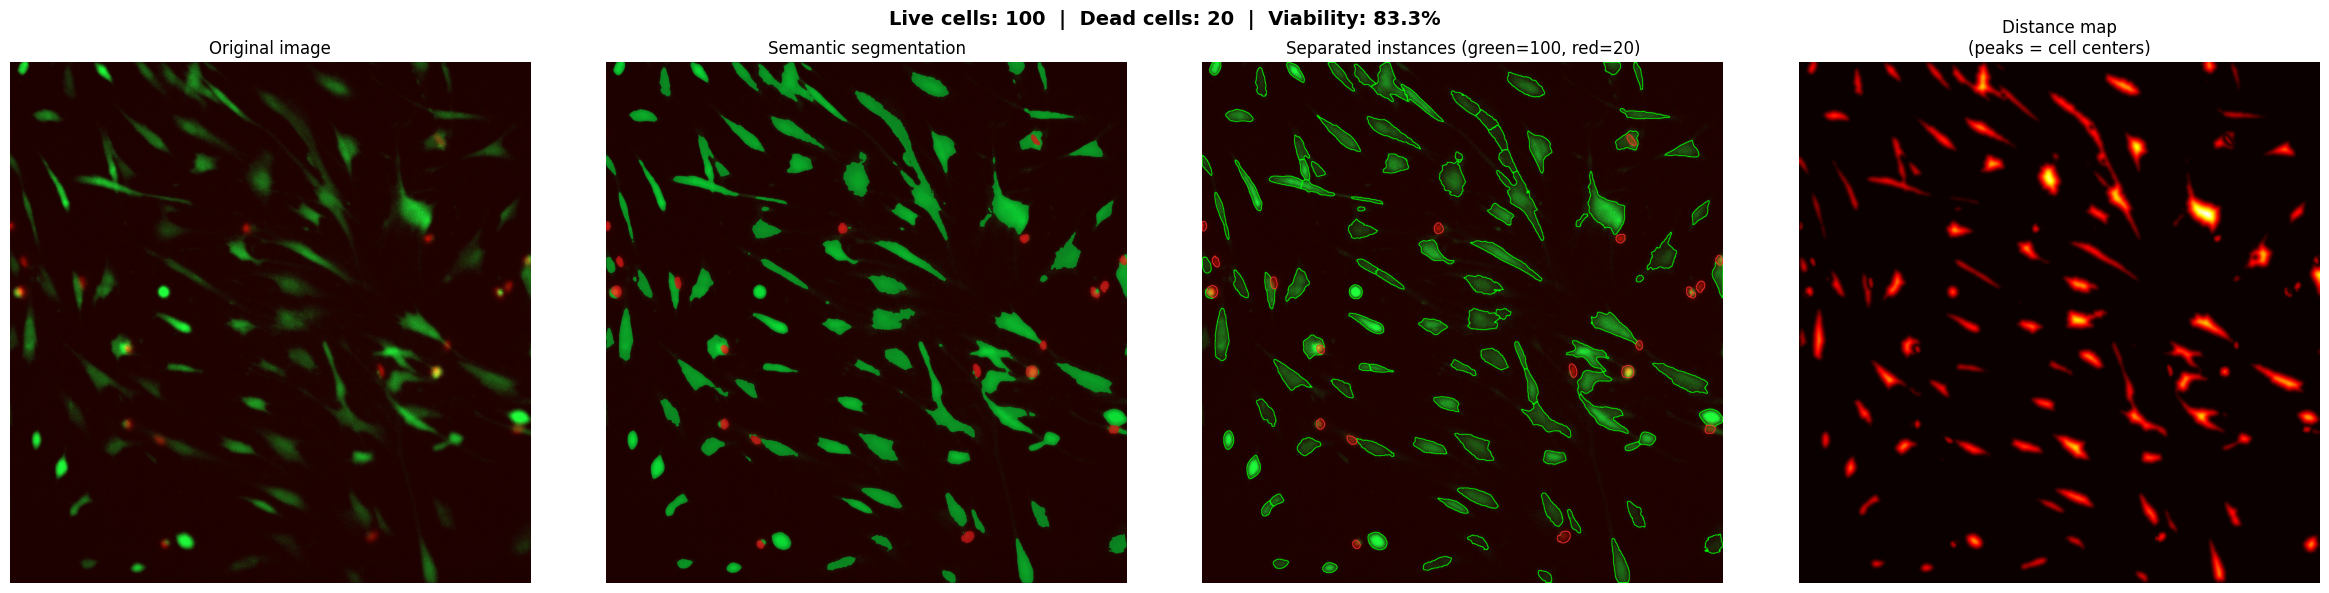

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 14 · Single-image inference example
# ─────────────────────────────────────────────────────────────────────────────
# Runs the full inference and post-processing pipeline on one image and
# displays the 4-panel diagnostic figure (original | segmentation |
# instances | distance map).

IMG_PATH = "/content/drive/MyDrive/FINAL_IMAGES(sin_augmentation)/Image0011.jpg"

image      = cv2.imread(IMG_PATH)
image      = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
print(f"Image shape: {image.shape}")

print("Running inference...")
prob_map = predict_full_image(model, image, preprocess_input)

# Separate instances for live and dead cells
labels_green, n_green = separate_instances(prob_map, image_gray,
                                           CLASS_CONFIG['green'])
labels_red,   n_red   = separate_instances(prob_map, image_gray,
                                           CLASS_CONFIG['red'])

print(f"Live cells:  {n_green}")
print(f"Dead cells:  {n_red}")
if (n_green + n_red) > 0:
    print(f"Viability:   {n_green / (n_green + n_red) * 100:.1f}%")

visualize_result(image, prob_map, labels_green, labels_red, n_green, n_red)


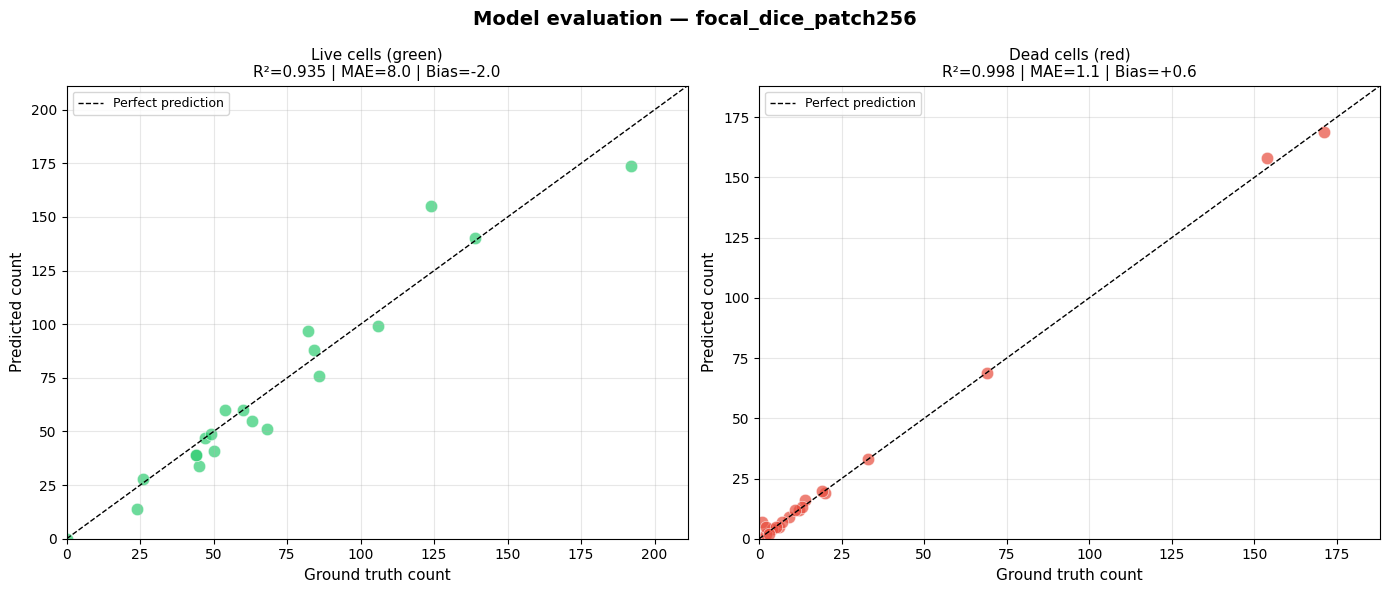

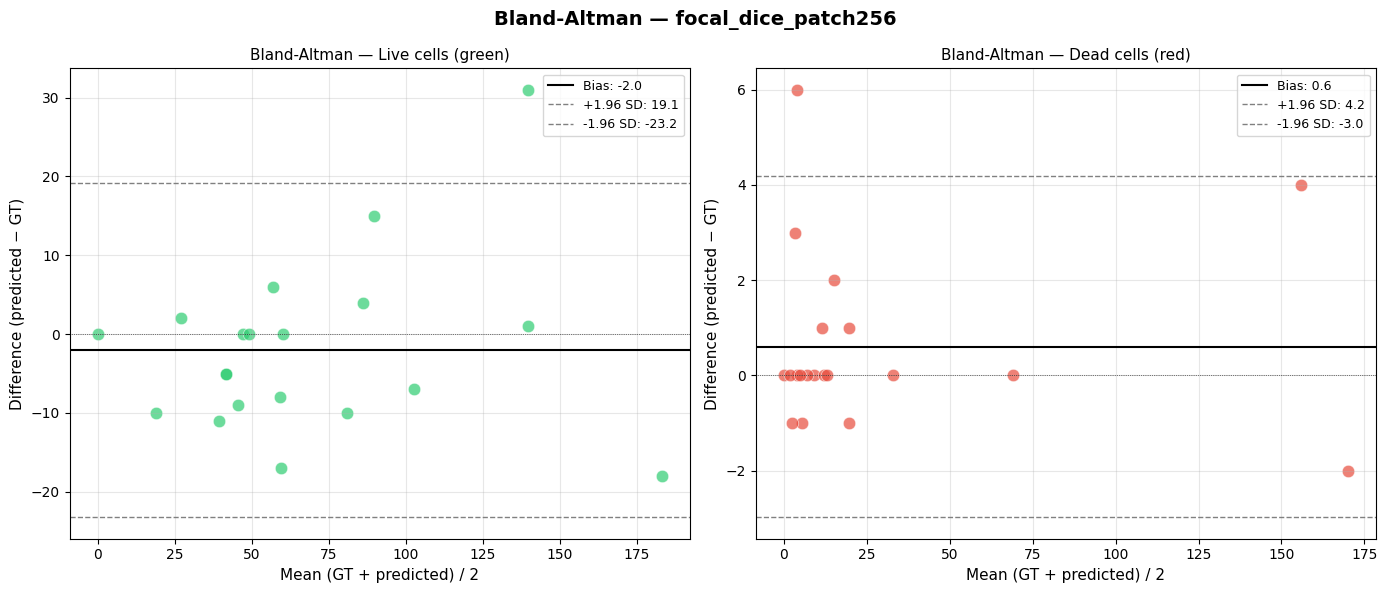

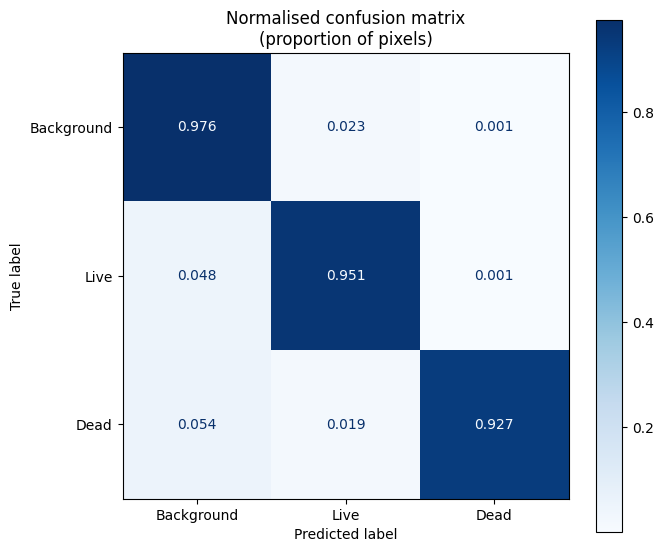

Selected images: ['Image0005.jpg', 'Image0030.jpg', 'Image0028.jpg']



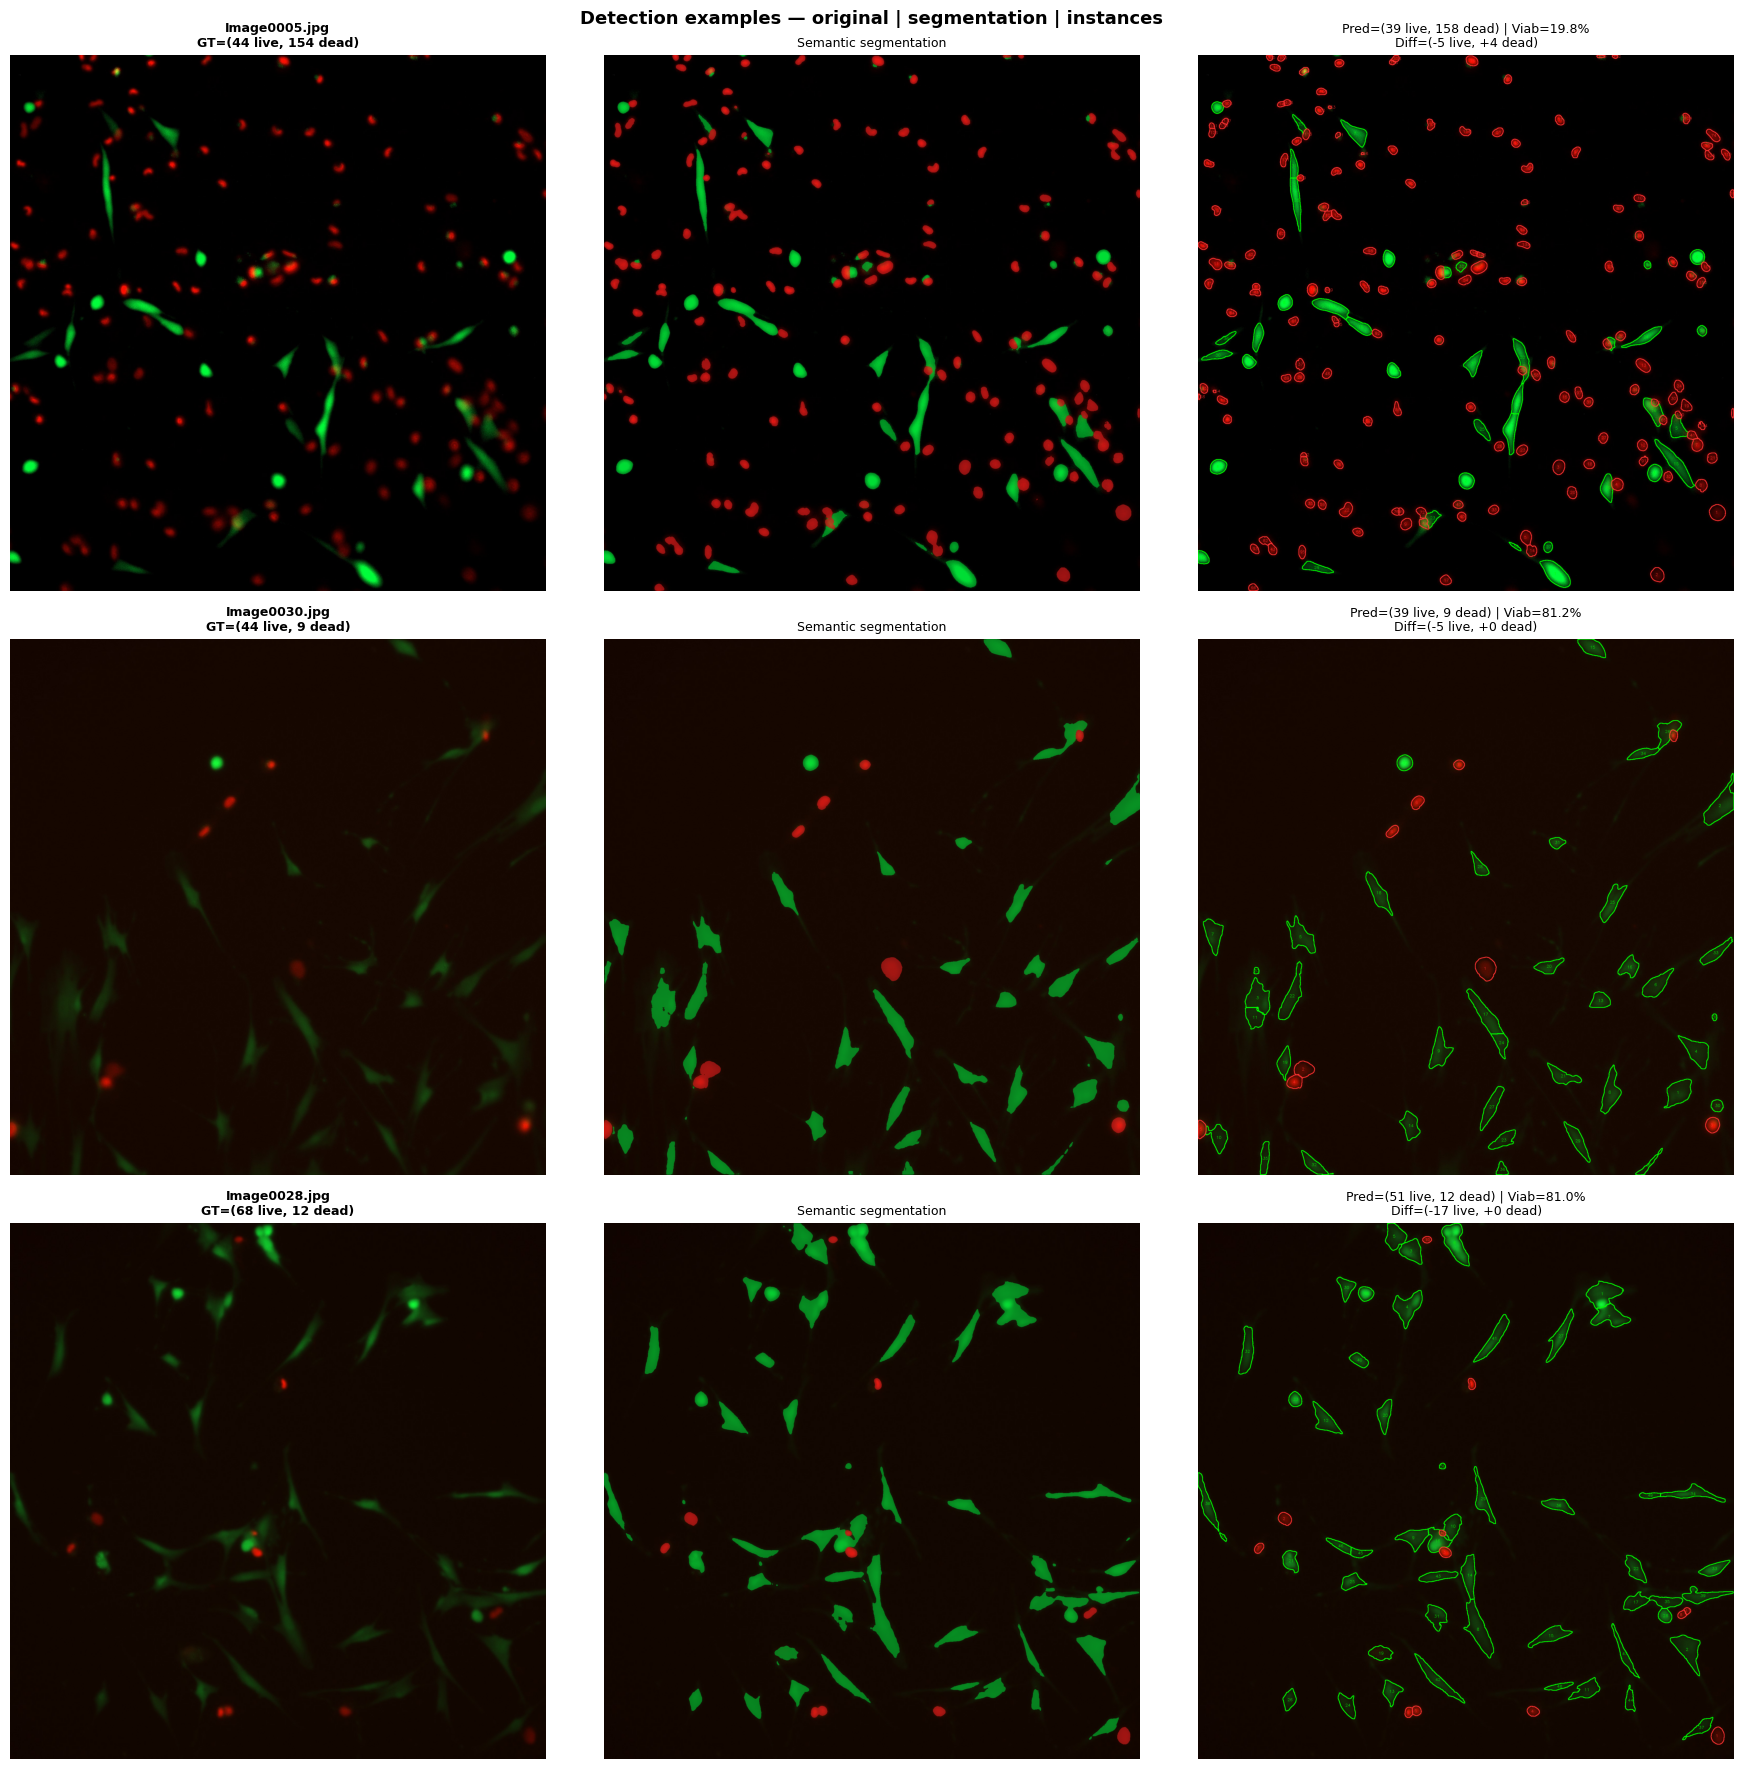

Figures generated — run next cell to save


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 15 · Generate evaluation figures
# ─────────────────────────────────────────────────────────────────────────────
# Produces four publication-ready figures:
#
#   fig1 — Scatter plots (GT vs Predicted) with R² for live and dead cells.
#   fig2 — Bland-Altman plots assessing systematic bias and limits of agreement.
#   fig3 — Normalised confusion matrix at the pixel level.
#   fig4 — Qualitative examples: 3 random validation images showing
#           original | semantic segmentation | instance contours.

# ── Figure 1 · Scatter R² ─────────────────────────────────────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(14, 6))
fig1.suptitle("Model evaluation — focal_dice_patch256",
              fontsize=14, fontweight='bold')

for i, (gt, pred, name, color, mae, r2, bias) in enumerate([
    (gt_g, pred_g, 'Live cells (green)',  '#2ecc71', mae_g, r2_g, bias_g),
    (gt_r, pred_r, 'Dead cells (red)',    '#e74c3c', mae_r, r2_r, bias_r),
]):
    ax  = axes[i]
    ax.scatter(gt, pred, color=color, alpha=0.7,
               edgecolors='white', linewidth=0.5, s=80)
    lim = max(gt.max(), pred.max()) * 1.1
    ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel("Ground truth count", fontsize=11)
    ax.set_ylabel("Predicted count",    fontsize=11)
    ax.set_title(f"{name}\nR²={r2:.3f} | MAE={mae:.1f} | Bias={bias:+.1f}",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 2 · Bland-Altman ───────────────────────────────────────────────────
# The Bland-Altman plot assesses agreement between GT and predicted counts:
#   • Bias line       — mean difference (predicted − GT)
#   • ±1.96 SD lines  — 95 % limits of agreement
fig2, axes = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Bland-Altman — focal_dice_patch256",
              fontsize=14, fontweight='bold')

for i, (gt, pred, name, color) in enumerate([
    (gt_g, pred_g, 'Live cells (green)', '#2ecc71'),
    (gt_r, pred_r, 'Dead cells (red)',   '#e74c3c'),
]):
    ax        = axes[i]
    mean_vals = (gt + pred) / 2
    diff_vals = pred - gt
    mean_diff = np.mean(diff_vals)
    std_diff  = np.std(diff_vals)
    loa_upper = mean_diff + 1.96 * std_diff
    loa_lower = mean_diff - 1.96 * std_diff

    ax.scatter(mean_vals, diff_vals, color=color, alpha=0.7,
               edgecolors='white', linewidth=0.5, s=80)
    ax.axhline(mean_diff, color='black', linewidth=1.5,
               linestyle='-',  label=f'Bias: {mean_diff:.1f}')
    ax.axhline(loa_upper, color='gray',  linewidth=1,
               linestyle='--', label=f'+1.96 SD: {loa_upper:.1f}')
    ax.axhline(loa_lower, color='gray',  linewidth=1,
               linestyle='--', label=f'-1.96 SD: {loa_lower:.1f}')
    ax.axhline(0, color='black', linewidth=0.5, linestyle=':')
    ax.set_xlabel("Mean (GT + predicted) / 2", fontsize=11)
    ax.set_ylabel("Difference (predicted − GT)", fontsize=11)
    ax.set_title(f"Bland-Altman — {name}", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Figure 3 · Confusion matrix ───────────────────────────────────────────────
# Row-normalised (per GT class) so that values represent recall per class,
# independent of class frequency in the validation set.
cm   = confusion_matrix(np.array(all_gt_flat),
                        np.array(all_pred_flat),
                        normalize='true')
fig3, ax3 = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Background', 'Live', 'Dead']
)
disp.plot(ax=ax3, colorbar=True, cmap='Blues', values_format='.3f')
ax3.set_title("Normalised confusion matrix\n(proportion of pixels)",
              fontsize=12)
plt.tight_layout()
plt.show()

# ── Figure 4 · Qualitative examples (3 random validation images) ──────────────
def get_labels_with_gradient(binary_mask, cfg, image_gray):
    """Instance separation using gradient-guided watershed (used for display)."""
    binary = remove_small_objects(binary_mask.astype(bool),
                                  min_size=cfg['min_area_px'])
    if not binary.any():
        return np.zeros_like(binary, dtype=np.int32), 0
    dist        = ndi.distance_transform_edt(binary)
    dist_smooth = ndi.gaussian_filter(dist, sigma=cfg['sigma'])
    coords      = peak_local_max(dist_smooth,
                                 min_distance=cfg['min_distance'],
                                 labels=binary)
    if len(coords) == 0:
        return np.zeros_like(binary, dtype=np.int32), 0
    markers = np.zeros_like(binary, dtype=np.int32)
    for i, (r, c) in enumerate(coords):
        markers[r, c] = i + 1
    gradient = sobel(image_gray.astype(np.float32) / 255.0)
    terrain  = cfg['alpha'] * (1 - dist_smooth / (dist_smooth.max() + 1e-6)) + \
               (1 - cfg['alpha']) * gradient
    labels   = watershed(terrain, markers, mask=binary)
    n_cells  = len(np.unique(labels)) - 1
    return labels, max(n_cells, 0)


rng            = random.Random()
sample_indices = rng.sample(range(len(images_raw)), min(3, len(images_raw)))
print(f"Selected images: {[val_files[i] for i in sample_indices]}\n")

fig4, axes4 = plt.subplots(3, 3, figsize=(18, 18))
fig4.suptitle("Detection examples — original | segmentation | instances",
              fontsize=13, fontweight='bold')

for row, idx in enumerate(sample_indices):
    image      = images_raw[idx]
    prob_map   = prob_maps[idx]
    pred_class = np.argmax(prob_map, axis=-1).astype(np.int32)
    img_file   = val_files[idx]
    image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)

    labels_green, n_green = get_labels_with_gradient(
        pred_class == 1, CLASS_CONFIG['green'], image_gray)
    labels_red,   n_red   = get_labels_with_gradient(
        pred_class == 2, CLASS_CONFIG['red'],   image_gray)

    gt_green = GT_COUNTS[img_file]['green']
    gt_red   = GT_COUNTS[img_file]['red']
    total    = n_green + n_red
    viab     = n_green / total * 100 if total > 0 else 0

    # Column 0: original image with GT annotation in title
    axes4[row, 0].imshow(image)
    axes4[row, 0].set_title(f"{img_file}\nGT=({gt_green} live, {gt_red} dead)",
                             fontsize=9, fontweight='bold')
    axes4[row, 0].axis('off')

    # Column 1: semantic segmentation overlay
    overlay    = image.copy().astype(np.float32)
    green_mask = prob_map[:, :, 1] > CLASS_CONFIG['green']['min_prob']
    red_mask   = prob_map[:, :, 2] > CLASS_CONFIG['red']['min_prob']
    overlay[green_mask] = overlay[green_mask] * 0.4 + np.array([0, 200, 50])  * 0.6
    overlay[red_mask]   = overlay[red_mask]   * 0.4 + np.array([220, 30, 30]) * 0.6
    axes4[row, 1].imshow(overlay.clip(0, 255).astype(np.uint8))
    axes4[row, 1].set_title("Semantic segmentation", fontsize=9)
    axes4[row, 1].axis('off')

    # Column 2: individual instances with numeric labels
    instance_vis = image.copy().astype(np.uint8)
    for lid in np.unique(labels_green):
        if lid == 0: continue
        mask = (labels_green == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (0, 255, 0), 2)
        M = cv2.moments(mask)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(instance_vis, str(lid), (cx-8, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    for lid in np.unique(labels_red):
        if lid == 0: continue
        mask = (labels_red == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (255, 50, 50), 2)
        M = cv2.moments(mask)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(instance_vis, str(lid), (cx-8, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 50, 50), 1)

    axes4[row, 2].imshow(instance_vis)
    axes4[row, 2].set_title(
        f"Pred=({n_green} live, {n_red} dead) | Viab={viab:.1f}%\n"
        f"Diff=({n_green-gt_green:+d} live, {n_red-gt_red:+d} dead)",
        fontsize=9)
    axes4[row, 2].axis('off')

plt.tight_layout()
plt.show()

print("Figures generated — run next cell to save")


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 16 · Save evaluation figures to Google Drive (300 dpi)
# ─────────────────────────────────────────────────────────────────────────────
save_dir = "/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256"
os.makedirs(save_dir, exist_ok=True)

fig1.savefig(os.path.join(save_dir, "scatter_r2.png"),
             dpi=300, bbox_inches='tight')
print("scatter_r2.png saved")

fig2.savefig(os.path.join(save_dir, "bland_altman.png"),
             dpi=300, bbox_inches='tight')
print("bland_altman.png saved")

fig3.savefig(os.path.join(save_dir, "confusion_matrix.png"),
             dpi=300, bbox_inches='tight')
print("confusion_matrix.png saved")

print(f"\nFigures saved to: {save_dir}")


scatter_r2.png saved
bland_altman.png saved
confusion_matrix.png saved

Figures saved to: /content/drive/MyDrive/live_dead_project/models/focal_dice_patch256


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 17 · Save fixed qualitative detection examples (300 dpi)
# ─────────────────────────────────────────────────────────────────────────────
# Uses a fixed list of three validation images (instead of random sampling)
# to produce deterministic, reproducible qualitative figures for the paper.
# Each figure shows: original | semantic segmentation | detected instances.

save_dir = "/content/drive/MyDrive/live_dead_project/models/focal_dice_patch256"
os.makedirs(save_dir, exist_ok=True)

FIXED_IMAGES   = ['Image0005.jpg', 'Image0030.jpg', 'Image0028.jpg']
sample_indices = [val_files.index(f) for f in FIXED_IMAGES if f in val_files]
print(f"Selected images: {[val_files[i] for i in sample_indices]}\n")

for row, idx in enumerate(sample_indices):
    image      = images_raw[idx]
    prob_map   = prob_maps[idx]
    pred_class = np.argmax(prob_map, axis=-1).astype(np.int32)
    img_file   = val_files[idx]
    image_gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    name       = img_file.replace('.jpg','').replace('.png','').replace('.tiff','')

    labels_green, n_green = get_labels_with_gradient(
        pred_class == 1, CLASS_CONFIG['green'], image_gray)
    labels_red,   n_red   = get_labels_with_gradient(
        pred_class == 2, CLASS_CONFIG['red'],   image_gray)

    gt_green = GT_COUNTS[img_file]['green']
    gt_red   = GT_COUNTS[img_file]['red']
    total    = n_green + n_red
    viab     = n_green / total * 100 if total > 0 else 0

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(
        f"{img_file} — GT=({gt_green} live, {gt_red} dead) | "
        f"Pred=({n_green} live, {n_red} dead) | "
        f"Viab={viab:.1f}% | "
        f"Diff=({n_green-gt_green:+d} live, {n_red-gt_red:+d} dead)",
        fontsize=11, fontweight='bold'
    )

    axes[0].imshow(image)
    axes[0].set_title("Original image", fontsize=10)
    axes[0].axis('off')

    overlay    = image.copy().astype(np.float32)
    green_mask = prob_map[:, :, 1] > CLASS_CONFIG['green']['min_prob']
    red_mask   = prob_map[:, :, 2] > CLASS_CONFIG['red']['min_prob']
    overlay[green_mask] = overlay[green_mask] * 0.4 + np.array([0, 200, 50])  * 0.6
    overlay[red_mask]   = overlay[red_mask]   * 0.4 + np.array([220, 30, 30]) * 0.6
    axes[1].imshow(overlay.clip(0, 255).astype(np.uint8))
    axes[1].set_title("Semantic segmentation", fontsize=10)
    axes[1].axis('off')

    instance_vis = image.copy().astype(np.uint8)
    for lid in np.unique(labels_green):
        if lid == 0: continue
        mask = (labels_green == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (0, 255, 0), 2)
        M = cv2.moments(mask)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(instance_vis, str(lid), (cx-8, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 1)
    for lid in np.unique(labels_red):
        if lid == 0: continue
        mask = (labels_red == lid).astype(np.uint8)
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                       cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(instance_vis, contours, -1, (255, 50, 50), 2)
        M = cv2.moments(mask)
        if M['m00'] > 0:
            cx = int(M['m10'] / M['m00'])
            cy = int(M['m01'] / M['m00'])
            cv2.putText(instance_vis, str(lid), (cx-8, cy+5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 50, 50), 1)

    axes[2].imshow(instance_vis)
    axes[2].set_title("Detected instances", fontsize=10)
    axes[2].axis('off')

    plt.tight_layout()

    out_path = os.path.join(save_dir, f"example_{row+1}_{name}.png")
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.close(fig)
    print(f"Saved: example_{row+1}_{name}.png")

print(f"\n3 example images saved to: {save_dir}")


Selected images: ['Image0005.jpg', 'Image0030.jpg', 'Image0028.jpg']

Saved: example_1_Image0005.png
Saved: example_2_Image0030.png
Saved: example_3_Image0028.png

3 example images saved to: /content/drive/MyDrive/live_dead_project/models/focal_dice_patch256
